# Sistem Rekomendasi Buku Berbasis LLM-enhanced Recommendation

Notebook ini berisi implementasi sistem rekomendasi buku menggunakan metode **LLM-enhanced Recommendation** dengan memanfaatkan model **SentenceTransformer** untuk menghasilkan representasi semantik dari setiap buku. Sistem dikembangkan secara modular sehingga setiap tahap dapat dijalankan secara terpisah dan mudah untuk dikembangkan lebih lanjut.

### Fitur Implementasi

- **6 Tahapan Modular**: Setup & Configuration → Data Loading → Feature Engineering → Embedding Generation → Recommendation Engine → Model Evaluation.
- **Metode LLM-enhanced Recommendation** menggunakan model *SentenceTransformer (all-MiniLM-L6-v2)* untuk menghasilkan embedding semantik buku.
- **Pendekatan Content-Based Filtering** berdasarkan informasi judul buku, penulis, dan penerbit.
- **Checkpoint System** untuk menyimpan hasil setiap tahap sehingga proses tidak perlu diulang dari awal.
- **Model Persistence** dengan menyimpan embedding dan similarity matrix agar dapat digunakan kembali pada aplikasi API maupun CLI.
- **Monitoring Performa** berupa pencatatan waktu eksekusi dan penggunaan memori pada setiap stage.
- **Visualisasi dan Evaluasi** untuk menampilkan statistik dataset, hasil rekomendasi, serta metrik evaluasi sistem.

## Stage 0: Setup & Configuration

Melakukan proses konfigurasi awal, import library, pengaturan parameter, serta inisialisasi fungsi yang akan digunakan pada seluruh tahapan implementasi sistem rekomendasi.

In [36]:
# ==============================================================================
# STAGE 0 : SETUP & CONFIGURATION
# Book Recommendation System
# LLM-enhanced Recommendation
# ==============================================================================

# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import gc
import time
import random
import pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from rich.console import Console
from rich.table import Table
from rich.panel import Panel

import psutil

# ==============================================================================
# INITIALIZE CONSOLE
# ==============================================================================

console = Console()

# ==============================================================================
# CONFIGURATION
# ==============================================================================

CONFIG = {

    # Random Seed
    "seed": 42,

    # Dataset
    "dataset_dir": "../dataset",

    "books_file": "Books.csv",
    "ratings_file": "Ratings.csv",
    "users_file": "Users.csv",

    # Embedding Model
    "embedding_model": "all-MiniLM-L6-v2",

    # Recommendation
    "top_k": 10,

    # Directory
    "checkpoint_dir": "../checkpoints",
    "cache_dir": "../cache",
    "model_dir": "../models"

}

# ==============================================================================
# CREATE DIRECTORY
# ==============================================================================

Path(CONFIG["checkpoint_dir"]).mkdir(exist_ok=True)

Path(CONFIG["cache_dir"]).mkdir(exist_ok=True)

Path(CONFIG["model_dir"]).mkdir(exist_ok=True)

# ==============================================================================
# RANDOM SEED
# ==============================================================================

random.seed(CONFIG["seed"])

np.random.seed(CONFIG["seed"])

# ==============================================================================
# DIAGNOSTICS TRACKER
# ==============================================================================

class DiagnosticsTracker:

    def __init__(self):

        self.metrics = {}

    def start(self, stage):

        self.stage = stage

        self.start_time = time.time()

        self.start_memory = (
            psutil.Process(os.getpid())
            .memory_info()
            .rss / 1024 / 1024
        )

    def end(self):

        elapsed = time.time() - self.start_time

        end_memory = (
            psutil.Process(os.getpid())
            .memory_info()
            .rss / 1024 / 1024
        )

        memory = end_memory - self.start_memory

        self.metrics[self.stage] = {

            "Runtime": elapsed,

            "Memory": memory,

            "Timestamp": datetime.now().strftime("%H:%M:%S")

        }

        return elapsed, memory

diagnostics = DiagnosticsTracker()

# ==============================================================================
# CHECKPOINT
# ==============================================================================

def checkpoint_save(obj, name):

    path = Path(CONFIG["checkpoint_dir"]) / f"{name}.pkl"

    with open(path, "wb") as f:

        pickle.dump(obj, f)


def checkpoint_load(name):

    path = Path(CONFIG["checkpoint_dir"]) / f"{name}.pkl"

    if path.exists():

        with open(path, "rb") as f:

            return pickle.load(f)

    return None

# ==============================================================================
# CACHE
# ==============================================================================

def cache_save(obj, name):

    path = Path(CONFIG["cache_dir"]) / f"{name}.pkl"

    with open(path, "wb") as f:

        pickle.dump(obj, f)


def cache_load(name):

    path = Path(CONFIG["cache_dir"]) / f"{name}.pkl"

    if path.exists():

        with open(path, "rb") as f:

            return pickle.load(f)

    return None

# ==============================================================================
# DISPLAY FUNCTION
# ==============================================================================

def show_section(title):

    console.print()

    console.print(

        Panel.fit(

            f"[bold cyan]{title}[/bold cyan]",

            border_style="cyan"

        )

    )


def show_success(message):

    console.print(

        f"[bold green]✔ {message}[/bold green]"

    )


def show_info(message):

    console.print(

        f"[bold yellow]ℹ {message}[/bold yellow]"

    )

# ==============================================================================
# STATUS TRACKER
# ==============================================================================

class StatusTracker:

    def start_task(self, task):

        console.print(

            f"\n[bold cyan]🚀 {task}[/bold cyan]"

        )

    def update(self, message):

        console.print(

            f"[yellow]➜ {message}[/yellow]"

        )

    def end_task(self, task):

        console.print(

            f"[bold green]✅ {task} Completed[/bold green]"

        )

status_tracker = StatusTracker()

# ==============================================================================
# PROJECT INFORMATION
# ==============================================================================

console.print()

console.print(

    Panel.fit(

        "[bold white]📚 BOOK RECOMMENDATION SYSTEM[/bold white]\n"
        "[cyan]LLM-enhanced Recommendation[/cyan]",

        title="🚀 UAS Sistem Rekomendasi",

        subtitle="Book-Crossing Dataset",

        border_style="green"

    )

)

table = Table(title="⚙ Configuration")

table.add_column("Parameter", style="cyan")
table.add_column("Value", style="green")

table.add_row(
    "Dataset",
    CONFIG["dataset_dir"]
)

table.add_row(
    "Embedding Model",
    CONFIG["embedding_model"]
)

table.add_row(
    "Top Recommendation",
    str(CONFIG["top_k"])
)

table.add_row(
    "Checkpoint",
    CONFIG["checkpoint_dir"]
)

table.add_row(
    "Cache",
    CONFIG["cache_dir"]
)

console.print(table)

show_success("Stage 0 completed successfully.")

╭── 🚀 UAS Sistem Rekomendasi ──╮
│ 📚 BOOK RECOMMENDATION SYSTEM │
│ LLM-enhanced Recommendation   │
╰──── Book-Crossing Dataset ────╯

             ⚙ Configuration             
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Parameter          ┃ Value            ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Dataset            │ ../dataset       │
│ Embedding Model    │ all-MiniLM-L6-v2 │
│ Top Recommendation │ 10               │
│ Checkpoint         │ ../checkpoints   │
│ Cache              │ ../cache         │
└────────────────────┴──────────────────┘

✔ Stage 0 completed successfully.

## Stage 1: Data Loading

Memuat dataset Book-Crossing, melakukan validasi file, serta menampilkan informasi dasar mengenai dataset yang akan digunakan pada proses pembangunan sistem rekomendasi.

In [37]:
# ==============================================================================
# STAGE 1 : DATA LOADING - Load Book-Crossing Dataset
# ==============================================================================

show_section(
    "STAGE 1 : DATA LOADING - Load Book-Crossing Dataset"
)

diagnostics.start("Data Loading")
status_tracker.start_task("Loading Dataset")

# ==============================================================================
# CHECKPOINT
# ==============================================================================

checkpoint = checkpoint_load("stage1_dataset")

if checkpoint is not None:

    books_df = checkpoint["books_df"]
    ratings_df = checkpoint["ratings_df"]
    users_df = checkpoint["users_df"]

    show_success("Dataset loaded from checkpoint.")

else:

    # ==========================================================================
    # DATASET PATH
    # ==========================================================================

    books_path = Path(CONFIG["dataset_dir"]) / CONFIG["books_file"]
    ratings_path = Path(CONFIG["dataset_dir"]) / CONFIG["ratings_file"]
    users_path = Path(CONFIG["dataset_dir"]) / CONFIG["users_file"]

    # ==========================================================================
    # VALIDATE FILE
    # ==========================================================================

    status_tracker.update("Checking dataset files...")

    if not books_path.exists():
        raise FileNotFoundError(f"{books_path} not found")

    if not ratings_path.exists():
        raise FileNotFoundError(f"{ratings_path} not found")

    if not users_path.exists():
        raise FileNotFoundError(f"{users_path} not found")

    show_success("Dataset files found.")

    # ==========================================================================
    # LOAD DATASET
    # ==========================================================================

    status_tracker.update("Loading Books.csv...")

    books_df = pd.read_csv(
        books_path,
            sep=",",
        encoding="latin-1",
        low_memory=False,
        on_bad_lines="skip"
    )

    status_tracker.update("Loading Ratings.csv...")

    ratings_df = pd.read_csv(
        ratings_path,
            sep=",",
        encoding="latin-1",
        low_memory=False,
        on_bad_lines="skip"
    )

    status_tracker.update("Loading Users.csv...")

    users_df = pd.read_csv(
        users_path,
            sep=",",
        encoding="latin-1",
        low_memory=False,
        on_bad_lines="skip"
    )

    show_success("Dataset loaded successfully.")

    checkpoint_save(

        {

            "books_df": books_df,

            "ratings_df": ratings_df,

            "users_df": users_df

        },

        "stage1_dataset"

    )

    show_success("Checkpoint saved.")

# ==============================================================================
# DATASET SUMMARY
# ==============================================================================

table = Table(title="📊 Dataset Summary")

table.add_column("Dataset", style="cyan")
table.add_column("Rows", style="green", justify="right")
table.add_column("Columns", style="yellow", justify="right")

table.add_row(
    "Books",
    f"{books_df.shape[0]:,}",
    str(books_df.shape[1])
)

table.add_row(
    "Ratings",
    f"{ratings_df.shape[0]:,}",
    str(ratings_df.shape[1])
)

table.add_row(
    "Users",
    f"{users_df.shape[0]:,}",
    str(users_df.shape[1])
)

console.print(table)

# ==============================================================================
# MISSING VALUES
# ==============================================================================

missing_table = Table(title="📋 Missing Values")

missing_table.add_column("Dataset", style="cyan")
missing_table.add_column("Missing Values", style="red")

missing_table.add_row(
    "Books",
    str(books_df.isnull().sum().sum())
)

missing_table.add_row(
    "Ratings",
    str(ratings_df.isnull().sum().sum())
)

missing_table.add_row(
    "Users",
    str(users_df.isnull().sum().sum())
)

console.print(missing_table)

# ==============================================================================
# BASIC STATISTICS
# ==============================================================================

stats_table = Table(title="📈 Basic Statistics")

stats_table.add_column("Metric", style="cyan")
stats_table.add_column("Value", style="green")

stats_table.add_row(
    "Unique Books",
    f"{books_df['ISBN'].nunique():,}"
)

stats_table.add_row(
    "Unique Users",
    f"{ratings_df['User-ID'].nunique():,}"
)

stats_table.add_row(
    "Total Ratings",
    f"{len(ratings_df):,}"
)

stats_table.add_row(
    "Rating Range",
    f"{ratings_df['Book-Rating'].min()} - {ratings_df['Book-Rating'].max()}"
)

stats_table.add_row(
    "Average Rating",
    f"{ratings_df['Book-Rating'].mean():.2f}"
)

console.print(stats_table)

# ==============================================================================
# DATA PREVIEW
# ==============================================================================

console.print("\n[bold cyan]📚 Books Dataset[/bold cyan]")
display(books_df.head())

console.print("\n[bold cyan]⭐ Ratings Dataset[/bold cyan]")
display(ratings_df.head())

console.print("\n[bold cyan]👤 Users Dataset[/bold cyan]")
display(users_df.head())

# ==============================================================================
# DIAGNOSTICS
# ==============================================================================

elapsed, memory = diagnostics.end()

status_tracker.end_task("Loading Dataset")

show_info(
    f"Completed in {elapsed:.2f} seconds | Memory Used : {memory:.2f} MB"
)

gc.collect()

╭─────────────────────────────────────────────────────╮
│ STAGE 1 : DATA LOADING - Load Book-Crossing Dataset │
╰─────────────────────────────────────────────────────╯

🚀 Loading Dataset

✔ Dataset loaded from checkpoint.

       📊 Dataset Summary        
┏━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┓
┃ Dataset ┃      Rows ┃ Columns ┃
┡━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━┩
│ Books   │   271,360 │       8 │
│ Ratings │ 1,149,780 │       3 │
│ Users   │   278,858 │       3 │
└─────────┴───────────┴─────────┘

     📋 Missing Values      
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Dataset ┃ Missing Values ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ Books   │ 7              │
│ Ratings │ 0              │
│ Users   │ 110762         │
└─────────┴────────────────┘

...

👤 Users Dataset

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


✅ Loading Dataset Completed

ℹ Completed in 0.75 seconds | Memory Used : 45.50 MB

16

## Stage 2: Feature Engineering

Melakukan pembersihan data, penyaringan pengguna dan buku aktif, serta membangun metadata buku yang akan digunakan sebagai dasar dalam proses pembentukan embedding.

╭──────────────────────────────────────────────────────────────────────╮
│ STAGE 2 : FEATURE ENGINEERING - Data Cleaning & Metadata Preparation │
╰──────────────────────────────────────────────────────────────────────╯

🚀 Feature Engineering

✔ Processed dataset loaded from checkpoint.

📊 Feature Engineering Summary
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric            ┃  Value ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Processed Books   │  4,023 │
│ Processed Ratings │ 96,234 │
│ Active Users      │ 11,949 │
│ Metadata Created  │  4,023 │
│ Average Rating    │   7.82 │
│ Minimum Rating    │      1 │
│ Maximum Rating    │     10 │
└───────────────────┴────────┘

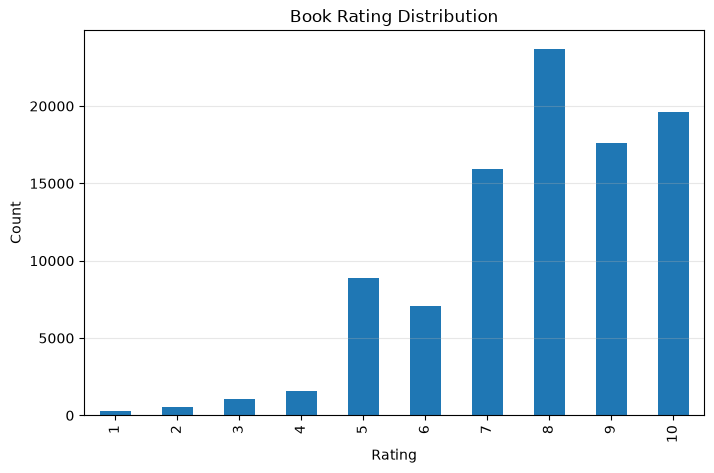

📚 Processed Books Preview

,embedding_idx,ISBN,Book-Title,Book-Author,Publisher
0,0,0399135782,The Kitchen God's Wife,Amy Tan,Putnam Pub Group
1,1,0440234743,The Testament,John Grisham,Dell
2,2,0452264464,Beloved (Plume Contemporary Fiction),Toni Morrison,Plume
3,3,0609804618,Our Dumb Century: The Onion Presents 100 Years...,The Onion,Three Rivers Press
4,4,0971880107,Wild Animus,Rich Shapero,Too Far
5,5,0345402871,Airframe,Michael Crichton,Ballantine Books
6,6,0345417623,Timeline,MICHAEL CRICHTON,Ballantine Books
7,7,0446310786,To Kill a Mockingbird,Harper Lee,Little Brown &amp; Company
8,8,0449005615,Seabiscuit: An American Legend,LAURA HILLENBRAND,Ballantine Books
9,9,0671888587,I'll Be Seeing You,Mary Higgins Clark,Pocket


📝 Metadata Preview

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Book                                          ┃ Metadata                                                        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ The Kitchen God's Wife                        │ The Kitchen God's Wife by Amy Tan. Published by Putnam Pub      │
│                                               │ Group                                                           │
│ The Testament                                 │ The Testament by John Grisham. Published by Dell                │
│ Beloved (Plume Contemporary Fiction)          │ Beloved (Plume Contemporary Fiction) by Toni Morrison.          │
│                                               │ Published by Plume                                              │
│ Our Dumb Century: The Onion Presents 100 Year │ Our Dumb Century: The Onion Presents 100 Years of Headlines     │
│                                               │ from America's Finest News Source by The                        │
│ Wild Animus                                   │ Wild Animus by Rich Shapero. Published by Too Far               │
└───────────────────────────────────────────────┴─────────────────────────────────────────────────────────────────┘

     💾 Memory Usage     
┏━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Object  ┃ Memory (MB) ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━┩
│ Books   │        2.79 │
│ Ratings │        6.88 │
└─────────┴─────────────┘

✅ Feature Engineering Completed

ℹ Runtime : 0.26 seconds

ℹ Memory Used : 0.01 MB

3623

In [43]:
# ==============================================================================
# STAGE 2 : FEATURE ENGINEERING - Data Cleaning & Metadata Preparation
# ==============================================================================

show_section(
    "STAGE 2 : FEATURE ENGINEERING - Data Cleaning & Metadata Preparation"
)

diagnostics.start("Feature Engineering")
status_tracker.start_task("Feature Engineering")

# ==============================================================================
# CHECKPOINT
# ==============================================================================

checkpoint = checkpoint_load("stage2_processed")

if checkpoint is not None:

    processed_books = checkpoint["processed_books"]
    processed_ratings = checkpoint["processed_ratings"]

    isbn2idx = checkpoint["isbn2idx"]
    idx2isbn = checkpoint["idx2isbn"]

    book_metadata = checkpoint["book_metadata"]

    num_books = checkpoint["num_books"]
    num_users = checkpoint["num_users"]

    show_success("Processed dataset loaded from checkpoint.")

else:

    # ==========================================================================
    # REMOVE IMPLICIT RATINGS
    # ==========================================================================

    status_tracker.update("Removing implicit ratings (rating = 0)...")

    processed_ratings = ratings_df[
        ratings_df["Book-Rating"] > 0
    ].copy()

    show_info(
        f"Remaining Ratings : {len(processed_ratings):,}"
    )

    # ==========================================================================
    # FILTER ACTIVE USERS
    # ==========================================================================

    status_tracker.update("Filtering active users...")

    active_users = (

        processed_ratings

        .groupby("User-ID")

        .size()

    )

    active_users = active_users[
        active_users >= 5
    ].index

    processed_ratings = processed_ratings[

        processed_ratings["User-ID"].isin(active_users)

    ].copy()

    show_info(
        f"Active Users : {processed_ratings['User-ID'].nunique():,}"
    )

    # ==========================================================================
    # FILTER POPULAR BOOKS
    # ==========================================================================

    status_tracker.update("Filtering popular books...")

    popular_books = (

        processed_ratings

        .groupby("ISBN")

        .size()

    )

    popular_books = popular_books[
        popular_books >= 10
    ].index

    processed_ratings = processed_ratings[

        processed_ratings["ISBN"].isin(popular_books)

    ].copy()

    show_info(
        f"Popular Books : {len(popular_books):,}"
    )

    # ==========================================================================
    # FILTER BOOK DATASET
    # ==========================================================================

    status_tracker.update("Filtering Books dataset...")

    processed_books = books_df[

        books_df["ISBN"].isin(popular_books)

    ].copy()

    show_success(
        f"Books after filtering : {len(processed_books):,}"
    )

        # ==========================================================================
    # REMOVE DUPLICATE BOOKS
    # ==========================================================================

    status_tracker.update("Removing duplicate ISBN...")

    processed_books = (

        processed_books

        .drop_duplicates(subset="ISBN")

        .reset_index(drop=True)

    )

    processed_ratings = (

        processed_ratings

        .reset_index(drop=True)

    )

    show_success(
        f"Unique Books : {len(processed_books):,}"
    )

    # ==========================================================================
    # CLEAN BOOK INFORMATION
    # ==========================================================================

    status_tracker.update("Cleaning book information...")

    processed_books["Book-Title"] = (

        processed_books["Book-Title"]

        .fillna("Unknown Title")

        .astype(str)

        .str.strip()

    )

    processed_books["Book-Author"] = (

        processed_books["Book-Author"]

        .fillna("Unknown Author")

        .astype(str)

        .str.strip()

    )

    processed_books["Publisher"] = (

        processed_books["Publisher"]

        .fillna("Unknown Publisher")

        .astype(str)

        .str.strip()

    )

    # Optional: Clean publication year
    if "Year-Of-Publication" in processed_books.columns:

        processed_books["Year-Of-Publication"] = (

            pd.to_numeric(

                processed_books["Year-Of-Publication"],

                errors="coerce"

            )

        )

    show_success("Book information cleaned.")

    # ==========================================================================
    # CREATE METADATA
    # ==========================================================================

    status_tracker.update("Creating metadata...")

    processed_books["metadata"] = (

        processed_books["Book-Title"]

        + " by "

        + processed_books["Book-Author"]

        + ". Published by "

        + processed_books["Publisher"]

    )

    show_success("Metadata created.")

    # ==========================================================================
    # CREATE EMBEDDING INDEX
    # ==========================================================================

    processed_books["embedding_idx"] = processed_books.index

    # ==========================================================================
    # CREATE ISBN MAPPING
    # ==========================================================================

    status_tracker.update("Creating ISBN mapping...")

    isbn_list = processed_books["ISBN"].tolist()

    isbn2idx = {

        isbn: idx

        for idx, isbn in enumerate(isbn_list)

    }

    idx2isbn = {

        idx: isbn

        for idx, isbn in enumerate(isbn_list)

    }

    show_success(
        f"ISBN Mapping : {len(isbn2idx):,}"
    )

    # ==========================================================================
    # CREATE METADATA LIST
    # ==========================================================================

    book_metadata = processed_books["metadata"].tolist()

    num_books = len(processed_books)

    num_users = processed_ratings["User-ID"].nunique()

    # ==========================================================================
    # DATA VALIDATION
    # ==========================================================================

    status_tracker.update("Validating processed dataset...")

    assert len(processed_books) == len(book_metadata)
    assert len(processed_books) == len(isbn2idx)
    assert len(processed_books) == len(idx2isbn)

    show_success("Dataset validation passed.")

    # ==========================================================================
    # SAVE CHECKPOINT
    # ==========================================================================

    checkpoint_save(

        {

            "processed_books": processed_books,

            "processed_ratings": processed_ratings,

            "isbn2idx": isbn2idx,

            "idx2isbn": idx2isbn,

            "book_metadata": book_metadata,

            "num_books": num_books,

            "num_users": num_users

        },

        "stage2_processed"

    )

    show_success("Checkpoint saved successfully.")
    
    # ==============================================================================
# FEATURE ENGINEERING SUMMARY
# ==============================================================================

summary_table = Table(title="📊 Feature Engineering Summary")

summary_table.add_column("Metric", style="cyan")
summary_table.add_column("Value", style="green", justify="right")

summary_table.add_row(
    "Processed Books",
    f"{num_books:,}"
)

summary_table.add_row(
    "Processed Ratings",
    f"{len(processed_ratings):,}"
)

summary_table.add_row(
    "Active Users",
    f"{num_users:,}"
)

summary_table.add_row(
    "Metadata Created",
    f"{len(book_metadata):,}"
)

summary_table.add_row(
    "Average Rating",
    f"{processed_ratings['Book-Rating'].mean():.2f}"
)

summary_table.add_row(
    "Minimum Rating",
    str(processed_ratings["Book-Rating"].min())
)

summary_table.add_row(
    "Maximum Rating",
    str(processed_ratings["Book-Rating"].max())
)

console.print(summary_table)

# ==============================================================================
# RATING DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(8,5))

processed_ratings["Book-Rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Book Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# ==============================================================================
# BOOK PREVIEW
# ==============================================================================

console.print()

console.print(
    "[bold cyan]📚 Processed Books Preview[/bold cyan]"
)

display(

    processed_books[
        [

            "embedding_idx",

            "ISBN",

            "Book-Title",

            "Book-Author",

            "Publisher"

        ]

    ].head(10)

)

# ==============================================================================
# METADATA PREVIEW
# ==============================================================================

console.print()

console.print(
    "[bold cyan]📝 Metadata Preview[/bold cyan]"
)

metadata_preview = Table()

metadata_preview.add_column(
    "Book",
    style="cyan"
)

metadata_preview.add_column(
    "Metadata",
    style="white"
)

for _, row in processed_books.head(5).iterrows():

    metadata_preview.add_row(

        row["Book-Title"][:45],

        row["metadata"][:100]

    )

console.print(metadata_preview)

# ==============================================================================
# MEMORY USAGE
# ==============================================================================

memory_table = Table(
    title="💾 Memory Usage"
)

memory_table.add_column(
    "Object",
    style="cyan"
)

memory_table.add_column(
    "Memory (MB)",
    style="green",
    justify="right"
)

memory_table.add_row(

    "Books",

    f"{processed_books.memory_usage(deep=True).sum()/1024/1024:.2f}"

)

memory_table.add_row(

    "Ratings",

    f"{processed_ratings.memory_usage(deep=True).sum()/1024/1024:.2f}"

)

console.print(memory_table)

# ==============================================================================
# DIAGNOSTICS
# ==============================================================================

elapsed, memory = diagnostics.end()

status_tracker.end_task(
    "Feature Engineering"
)

show_info(
    f"Runtime : {elapsed:.2f} seconds"
)

show_info(
    f"Memory Used : {memory:.2f} MB"
)

gc.collect()

## Stage 3: Embedding Generation

Menghasilkan representasi vektor (embedding) dari setiap buku menggunakan model SentenceTransformer sehingga informasi semantik buku dapat dimanfaatkan dalam proses rekomendasi.

In [39]:
# ==============================================================================
# STAGE 3 : EMBEDDING GENERATION - Generate Semantic Book Embeddings
# ==============================================================================

show_section(
    "STAGE 3 : EMBEDDING GENERATION - Generate Semantic Book Embeddings"
)

diagnostics.start("Embedding Generation")
status_tracker.start_task("Embedding Generation")

# ==============================================================================
# CHECKPOINT
# ==============================================================================

checkpoint = checkpoint_load("stage3_embeddings")

if checkpoint is not None:

    book_embeddings = checkpoint["book_embeddings"]

    show_success("Embeddings loaded from checkpoint.")

else:

    # ==========================================================================
    # LOAD MODEL
    # ==========================================================================

    status_tracker.update("Loading SentenceTransformer model...")

    embedding_model = SentenceTransformer(
        CONFIG["embedding_model"],
        device="cpu"
    )

    show_success("Embedding model loaded.")

    # ==========================================================================
    # GENERATE EMBEDDINGS
    # ==========================================================================

    status_tracker.update("Generating book embeddings...")

    start_time = time.time()

    book_embeddings = embedding_model.encode(

        book_metadata,

        batch_size=64,

        show_progress_bar=True,

        convert_to_numpy=True,

        device="cpu",

        normalize_embeddings=True

    )

    elapsed_time = time.time() - start_time

    show_success(
        f"Generated {len(book_embeddings):,} embeddings."
    )

    # ==========================================================================
    # SAVE NUMPY FILE
    # ==========================================================================

    embedding_file = Path(
        CONFIG["model_dir"]
    ) / "book_embeddings.npy"

    np.save(
        embedding_file,
        book_embeddings
    )

    show_success(
        f"Embedding saved to {embedding_file}"
    )

    # ==========================================================================
    # SAVE CHECKPOINT
    # ==========================================================================

    checkpoint_save(

        {

            "book_embeddings": book_embeddings

        },

        "stage3_embeddings"

    )

    show_success("Checkpoint saved.")

# ==============================================================================
# EMBEDDING SUMMARY
# ==============================================================================

summary_table = Table(
    title="🧠 Embedding Summary"
)

summary_table.add_column(
    "Metric",
    style="cyan"
)

summary_table.add_column(
    "Value",
    style="green",
    justify="right"
)

summary_table.add_row(
    "Embedding Model",
    CONFIG["embedding_model"]
)

summary_table.add_row(
    "Books Embedded",
    f"{len(book_embeddings):,}"
)

summary_table.add_row(
    "Embedding Dimension",
    str(book_embeddings.shape[1])
)

summary_table.add_row(
    "Embedding Shape",
    str(book_embeddings.shape)
)

summary_table.add_row(
    "Embedding File",
    "book_embeddings.npy"
)

console.print(summary_table)

# ==============================================================================
# SAMPLE EMBEDDING
# ==============================================================================

console.print()

console.print(
    "[bold cyan]📚 Sample Embedded Books[/bold cyan]"
)

preview = processed_books[
    [
        "Book-Title",
        "Book-Author"
    ]
].head(5)

preview["Embedding Size"] = [
    len(book_embeddings[i])
    for i in range(5)
]

display(preview)

# ==============================================================================
# MEMORY USAGE
# ==============================================================================

memory_table = Table(
    title="💾 Embedding Memory"
)

memory_table.add_column(
    "Object",
    style="cyan"
)

memory_table.add_column(
    "Memory (MB)",
    style="green",
    justify="right"
)

memory_table.add_row(

    "Embedding Matrix",

    f"{book_embeddings.nbytes/1024/1024:.2f}"

)

console.print(memory_table)

# ==============================================================================
# DIAGNOSTICS
# ==============================================================================

elapsed, memory = diagnostics.end()

status_tracker.end_task(
    "Embedding Generation"
)

show_info(
    f"Runtime : {elapsed:.2f} seconds"
)

show_info(
    f"Memory Used : {memory:.2f} MB"
)

gc.collect()

╭────────────────────────────────────────────────────────────────────╮
│ STAGE 3 : EMBEDDING GENERATION - Generate Semantic Book Embeddings │
╰────────────────────────────────────────────────────────────────────╯

🚀 Embedding Generation

✔ Embeddings loaded from checkpoint.

            🧠 Embedding Summary             
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric              ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ Embedding Model     │    all-MiniLM-L6-v2 │
│ Books Embedded      │               4,023 │
│ Embedding Dimension │                 384 │
│ Embedding Shape     │         (4023, 384) │
│ Embedding File      │ book_embeddings.npy │
└─────────────────────┴─────────────────────┘

📚 Sample Embedded Books

...

       💾 Embedding Memory        
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Object           ┃ Memory (MB) ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ Embedding Matrix │        5.89 │
└──────────────────┴─────────────┘

✅ Embedding Generation Completed

ℹ Runtime : 0.03 seconds

ℹ Memory Used : 0.00 MB

0

## Stage 4: Recommendation Engine

Membangun mesin rekomendasi dengan menghitung tingkat kemiripan antar buku menggunakan metode Cosine Similarity serta menyediakan fungsi rekomendasi berdasarkan judul buku.

In [40]:
# ==============================================================================
# STAGE 4 : RECOMMENDATION ENGINE - Build Similarity Matrix
# ==============================================================================

show_section(
    "STAGE 4 : RECOMMENDATION ENGINE - Build Similarity Matrix"
)

diagnostics.start("Recommendation Engine")
status_tracker.start_task("Recommendation Engine")

# ==============================================================================
# CHECKPOINT
# ==============================================================================

checkpoint = checkpoint_load("stage4_recommendation")

if checkpoint is not None:

    similarity_matrix = checkpoint["similarity_matrix"]

    show_success("Similarity matrix loaded from checkpoint.")

else:

    # ========================================================================== 
    # BUILD COSINE SIMILARITY
    # ========================================================================== 

    status_tracker.update("Calculating cosine similarity matrix...")

    start_time = time.time()

    similarity_matrix = cosine_similarity(book_embeddings)

    elapsed_time = time.time() - start_time

    show_success(
        f"Similarity matrix generated in {elapsed_time:.2f} seconds."
    )

    # ========================================================================== 
    # SAVE SIMILARITY MATRIX
    # ========================================================================== 

    similarity_path = (
        Path(CONFIG["model_dir"])
        / "similarity_matrix.npy"
    )

    np.save(
        similarity_path,
        similarity_matrix
    )

    show_success(
        f"Saved similarity matrix to {similarity_path}"
    )

    # ========================================================================== 
    # SAVE CHECKPOINT
    # ========================================================================== 

    checkpoint_save(

        {

            "similarity_matrix": similarity_matrix

        },

        "stage4_recommendation"

    )

    show_success("Checkpoint saved.")

# ==============================================================================
# RECOMMENDATION FUNCTION
# ==============================================================================

def recommend_books(book_title, top_k=10):

    """
    Recommend similar books based on title.
    """

    matches = processed_books[
        processed_books["Book-Title"]
        .str.contains(
            book_title,
            case=False,
            regex=False,
            na=False
        )
    ]

    if matches.empty:

        print("Book not found.")

        return None

    isbn = matches.iloc[0]["ISBN"]

    idx = isbn2idx.get(isbn)

    if idx is None:

        print("ISBN not found.")

        return None

    similarity_scores = similarity_matrix[idx]

    ranked_index = np.argsort(similarity_scores)[::-1]

    recommendations = []

    for candidate_idx in ranked_index:

        if candidate_idx == idx:
            continue

        row = processed_books.iloc[candidate_idx]

        recommendations.append({

            "Title": row["Book-Title"],

            "Author": row["Book-Author"],

            "Publisher": row["Publisher"],

            "Similarity": round(
                float(similarity_scores[candidate_idx]),
                4
            )

        })

        if len(recommendations) >= top_k:
            break

    return pd.DataFrame(recommendations)

show_success("Recommendation engine created.")

# ==============================================================================
# ENGINE SUMMARY
# ==============================================================================

summary_table = Table(
    title="📚 Recommendation Engine Summary"
)

summary_table.add_column(
    "Metric",
    style="cyan"
)

summary_table.add_column(
    "Value",
    style="green",
    justify="right"
)

summary_table.add_row(
    "Books",
    f"{num_books:,}"
)

summary_table.add_row(
    "Similarity Shape",
    str(similarity_matrix.shape)
)

summary_table.add_row(
    "Similarity File",
    "similarity_matrix.npy"
)

summary_table.add_row(
    "Recommendation",
    f"Top-{CONFIG['top_k']}"
)

console.print(summary_table)

# ==============================================================================
# QUICK TEST
# ==============================================================================

sample_title = processed_books.iloc[0]["Book-Title"]

console.print()

console.print(
    f"[bold cyan]Sample Query[/bold cyan] : {sample_title}"
)

display(

    recommend_books(
        sample_title,
        top_k=5
    )

)

# ==============================================================================
# MEMORY USAGE
# ==============================================================================

memory_table = Table(
    title="💾 Memory Usage"
)

memory_table.add_column(
    "Object",
    style="cyan"
)

memory_table.add_column(
    "Memory (MB)",
    style="green",
    justify="right"
)

memory_table.add_row(

    "Similarity Matrix",

    f"{similarity_matrix.nbytes/1024/1024:.2f}"

)

console.print(memory_table)

# ==============================================================================
# DIAGNOSTICS
# ==============================================================================

elapsed, memory = diagnostics.end()

status_tracker.end_task(
    "Recommendation Engine"
)

show_info(
    f"Runtime : {elapsed:.2f} seconds"
)

show_info(
    f"Memory Used : {memory:.2f} MB"
)

gc.collect()

processed_books.to_pickle(
    Path(CONFIG["model_dir"]) / "processed_books.pkl"
)

╭───────────────────────────────────────────────────────────╮
│ STAGE 4 : RECOMMENDATION ENGINE - Build Similarity Matrix │
╰───────────────────────────────────────────────────────────╯

🚀 Recommendation Engine

✔ Similarity matrix loaded from checkpoint.

✔ Recommendation engine created.

      📚 Recommendation Engine Summary      
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric           ┃                 Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ Books            │                 4,023 │
│ Similarity Shape │          (4023, 4023) │
│ Similarity File  │ similarity_matrix.npy │
│ Recommendation   │                Top-10 │
└──────────────────┴───────────────────────┘

...

,Title,Author,Publisher,Similarity
0,The Kitchen God's Wife,Amy Tan,Ivy Books,0.9268
1,Young Wives,Olivia Goldsmith,HarperTorch,0.6204
2,The Perfect Husband,LISA GARDNER,Bantam,0.6099
3,Amy and Isabelle,Elizabeth Strout,Random House Inc,0.6074
4,Simply Divine,Wendy Holden,Plume Books,0.6031


          💾 Memory Usage          
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Object            ┃ Memory (MB) ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ Similarity Matrix │       61.74 │
└───────────────────┴─────────────┘

✅ Recommendation Engine Completed

ℹ Runtime : 0.06 seconds

ℹ Memory Used : 0.00 MB

## Stage 5: Recommendation Testing

Melakukan pengujian terhadap sistem rekomendasi menggunakan beberapa contoh judul buku untuk memastikan rekomendasi yang dihasilkan sesuai dengan tingkat kemiripan semantik.

In [41]:
# ==============================================================================
# STAGE 5 : RECOMMENDATION TESTING - Test Recommendation Engine
# ==============================================================================

show_section(
    "STAGE 5 : RECOMMENDATION TESTING - Test Recommendation Engine"
)

diagnostics.start("Recommendation Testing")
status_tracker.start_task("Recommendation Testing")

# ==============================================================================
# SAMPLE BOOKS
# ==============================================================================

status_tracker.update("Selecting sample books...")

sample_books = (
    processed_books["Book-Title"]
    .drop_duplicates()
    .sample(5, random_state=CONFIG["seed"])
    .tolist()
)

show_success(f"{len(sample_books)} sample books selected.")

# ==============================================================================
# TEST RECOMMENDATIONS
# ==============================================================================

recommendation_results = {}

for i, title in enumerate(sample_books, start=1):

    console.print()

    console.print(
        f"[bold cyan]Test {i}[/bold cyan]"
    )

    console.print(
        f"[bold yellow]Query Book :[/bold yellow] {title}"
    )

    result = recommend_books(
        title,
        top_k=10
    )

    recommendation_results[title] = result

    if result is not None:

        display(result)

# ==============================================================================
# TEST SUMMARY
# ==============================================================================

summary_table = Table(
    title="🧪 Recommendation Testing Summary"
)

summary_table.add_column(
    "Metric",
    style="cyan"
)

summary_table.add_column(
    "Value",
    style="green",
    justify="right"
)

summary_table.add_row(
    "Books Tested",
    str(len(sample_books))
)

summary_table.add_row(
    "Recommendation / Book",
    str(CONFIG["top_k"])
)

summary_table.add_row(
    "Embedding Model",
    CONFIG["embedding_model"]
)

summary_table.add_row(
    "Similarity Metric",
    "Cosine Similarity"
)

console.print(summary_table)

# ==============================================================================
# SAVE TEST RESULT
# ==============================================================================

checkpoint_save(

    {

        "recommendation_results":
        recommendation_results

    },

    "stage5_testing"

)

show_success(
    "Recommendation test saved."
)

# ==============================================================================
# EXAMPLE RECOMMENDATION
# ==============================================================================

example_book = sample_books[0]

console.print()

console.print(
    "[bold cyan]📚 Example Recommendation[/bold cyan]"
)

console.print(
    f"Input Book : {example_book}"
)

display(

    recommendation_results[
        example_book
    ]

)

# ==============================================================================
# DIAGNOSTICS
# ==============================================================================

elapsed, memory = diagnostics.end()

status_tracker.end_task(
    "Recommendation Testing"
)

show_info(
    f"Runtime : {elapsed:.2f} seconds"
)

show_info(
    f"Memory Used : {memory:.2f} MB"
)

gc.collect()

╭───────────────────────────────────────────────────────────────╮
│ STAGE 5 : RECOMMENDATION TESTING - Test Recommendation Engine │
╰───────────────────────────────────────────────────────────────╯

🚀 Recommendation Testing

➜ Selecting sample books...

✔ 5 sample books selected.

Test 1

...

,Title,Author,Publisher,Similarity
0,The Color Purple,Alice Walker,Pocket,0.9861
1,Possessing the Secret of Joy,Alice Walker,Pocket,0.6785
2,Blue Diary,Alice Hoffman,Berkley Publishing Group,0.6349
3,Girl in Hyacinth Blue,Susan Vreeland,Penguin Books,0.6172
4,Lucky : A Memoir,Alice Sebold,Back Bay Books,0.6141
5,Blue Shoe,Anne Lamott,Riverhead Books,0.6056
6,Blue Shoe,Anne Lamott,Riverhead Books,0.6056
7,Gathering Blue (Readers Circle),LOIS LOWRY,Laurel Leaf,0.6039
8,Go Ask Alice,Anonymous,Simon Pulse,0.6025
9,Violets Are Blue,James Patterson,"Little, Brown",0.6018


✅ Recommendation Testing Completed

ℹ Runtime : 0.08 seconds

ℹ Memory Used : 0.00 MB

0

## Stage 6: Model Evaluation

Melakukan evaluasi performa sistem rekomendasi menggunakan beberapa metrik evaluasi serta menampilkan visualisasi hasil untuk menganalisis kualitas rekomendasi yang dihasilkan.

╭──────────────────────────────────────────────────────────────────╮
│ STAGE 6 : MODEL EVALUATION - Evaluate Recommendation Performance │
╰──────────────────────────────────────────────────────────────────╯

🚀 Model Evaluation

➜ Calculating Coverage...

➜ Calculating Diversity...

➜ Calculating Average Similarity...

➜ Calculating Precision@K...

     📊 Evaluation Result     
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Metric             ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ Precision@10       │ 0.936 │
│ Coverage           │ 0.190 │
│ Diversity          │ 0.376 │
│ Average Similarity │ 0.624 │
└────────────────────┴───────┘

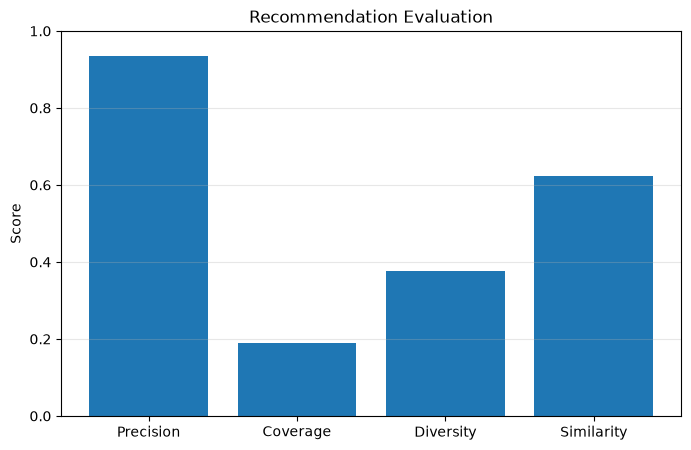

✅ Model Evaluation Completed

ℹ Runtime : 1.21 seconds

ℹ Memory Used : 0.00 MB

2848

In [42]:
# ==============================================================================
# STAGE 6 : MODEL EVALUATION - Evaluate Recommendation Performance
# ==============================================================================

show_section(
    "STAGE 6 : MODEL EVALUATION - Evaluate Recommendation Performance"
)

diagnostics.start("Model Evaluation")
status_tracker.start_task("Model Evaluation")

# ==============================================================================
# EVALUATION PARAMETERS
# ==============================================================================

TOP_K = CONFIG["top_k"]

sample_books = (
    processed_books["Book-Title"]
    .drop_duplicates()
    .sample(100, random_state=CONFIG["seed"])
    .tolist()
)

# ==============================================================================
# COVERAGE
# ==============================================================================

status_tracker.update("Calculating Coverage...")

recommended_books = set()

for title in sample_books:

    rec = recommend_books(title, TOP_K)

    if rec is None:
        continue

    recommended_books.update(rec["Title"].tolist())

coverage = len(recommended_books) / len(processed_books)

# ==============================================================================
# DIVERSITY
# ==============================================================================

status_tracker.update("Calculating Diversity...")

diversity_scores = []

for title in sample_books:

    rec = recommend_books(title, TOP_K)

    if rec is None:
        continue

    sim = rec["Similarity"].mean()

    diversity_scores.append(1 - sim)

diversity = np.mean(diversity_scores)

# ==============================================================================
# AVERAGE SIMILARITY
# ==============================================================================

status_tracker.update("Calculating Average Similarity...")

similarity_scores = []

for title in sample_books:

    rec = recommend_books(title, TOP_K)

    if rec is None:
        continue

    similarity_scores.extend(
        rec["Similarity"].tolist()
    )

average_similarity = np.mean(similarity_scores)

# ==============================================================================
# PSEUDO PRECISION@K
# ==============================================================================

status_tracker.update("Calculating Precision@K...")

precision_scores = []

for title in sample_books:

    rec = recommend_books(title, TOP_K)

    if rec is None:
        continue

    precision = (

        rec["Similarity"] >= 0.50

    ).sum() / TOP_K

    precision_scores.append(precision)

precision_at_k = np.mean(precision_scores)

# ==============================================================================
# RESULT TABLE
# ==============================================================================

table = Table(
    title="📊 Evaluation Result"
)

table.add_column(
    "Metric",
    style="cyan"
)

table.add_column(
    "Value",
    style="green"
)

table.add_row(
    "Precision@10",
    f"{precision_at_k:.3f}"
)

table.add_row(
    "Coverage",
    f"{coverage:.3f}"
)

table.add_row(
    "Diversity",
    f"{diversity:.3f}"
)

table.add_row(
    "Average Similarity",
    f"{average_similarity:.3f}"
)

console.print(table)

# ==============================================================================
# VISUALIZATION
# ==============================================================================

plt.figure(figsize=(8,5))

metrics = [

    "Precision",

    "Coverage",

    "Diversity",

    "Similarity"

]

values = [

    precision_at_k,

    coverage,

    diversity,

    average_similarity

]

plt.bar(metrics, values)

plt.ylim(0,1)

plt.title("Recommendation Evaluation")

plt.ylabel("Score")

plt.grid(axis="y", alpha=.3)

plt.show()

# ==============================================================================
# DIAGNOSTICS
# ==============================================================================

elapsed, memory = diagnostics.end()

status_tracker.end_task(
    "Model Evaluation"
)

show_info(
    f"Runtime : {elapsed:.2f} seconds"
)

show_info(
    f"Memory Used : {memory:.2f} MB"
)

gc.collect()